## Customer Sentiment Analysis 

## Project Overview

This projec analyzes 25000 customer reviews to understand customer sentiment, ratings, response time, complaints, and issue resolution.

The analysis uses Python for data cleaning, exploratory data analysis, visualization, sentiment analysis, and business insights.

## Tools & Technologies
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- NLTK / VADER
- Jupyter Notebook


## Import Required Libraries

In this section, the required python libraries are imported for data manipulation, analysis, visualization, and sentiment analysis.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load the Dataset

The customer sentiment dataset is loaded into a Pandas DataFrame for further analysis.

In [3]:
df = pd.read_csv("../data/Customer_Sentiment.csv")

## Initial Data Exploration

The first step is to understand the structure and size of the dataset.

The following operations are used to examine:

- Sample records
- Number of rows and columns
- Column names
- Data types
- Basic dataset structure

In [4]:
df.head()

,customer_id,gender,age_group,region,product_category,purchase_channel,platform,customer_rating,review_text,sentiment,response_time_hours,issue_resolved,complaint_registered
0,1,male,60+,north,automobile,online,flipkart,1,very disappointed with the quality.,negative,46,yes,yes
1,2,other,46-60,central,books,online,swiggy instamart,5,fast delivery and great packaging.,positive,5,yes,no
2,3,female,36-45,east,sports,online,facebook marketplace,1,very disappointed with the quality.,negative,38,yes,yes
3,4,female,18-25,central,groceries,online,zepto,2,product stopped working after few days.,negative,16,yes,yes
4,5,female,18-25,east,electronics,online,croma,3,neutral about the quality.,neutral,15,yes,no


In [8]:
df.tail()

,customer_id,gender,age_group,region,product_category,purchase_channel,platform,customer_rating,review_text,sentiment,response_time_hours,issue_resolved,complaint_registered
24995,24996,female,36-45,south,beauty,online,lenskart,1,very disappointed with the quality.,negative,40,yes,yes
24996,24997,other,60+,central,automobile,online,flipkart,5,"amazing experience, highly recommend!",positive,25,yes,no
24997,24998,male,18-25,south,beauty,online,ajio,4,fast delivery and great packaging.,positive,9,yes,no
24998,24999,female,26-35,central,automobile,online,snapdeal,5,great value for money.,positive,65,no,no
24999,25000,male,46-60,central,travel,online,lenskart,3,"product is okay, nothing special.",neutral,67,no,no


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   customer_id           25000 non-null  int64
 1   gender                25000 non-null  str  
 2   age_group             25000 non-null  str  
 3   region                25000 non-null  str  
 4   product_category      25000 non-null  str  
 5   purchase_channel      25000 non-null  str  
 6   platform              25000 non-null  str  
 7   customer_rating       25000 non-null  int64
 8   review_text           25000 non-null  str  
 9   sentiment             25000 non-null  str  
 10  response_time_hours   25000 non-null  int64
 11  issue_resolved        25000 non-null  str  
 12  complaint_registered  25000 non-null  str  
dtypes: int64(3), str(10)
memory usage: 2.5 MB


In [14]:
df.shape

(25000, 13)

In [15]:
df.dtypes

customer_id             int64
gender                    str
age_group                 str
region                    str
product_category          str
purchase_channel          str
platform                  str
customer_rating         int64
review_text               str
sentiment                 str
response_time_hours     int64
issue_resolved            str
complaint_registered      str
dtype: object

In [12]:
df.columns

Index(['customer_id', 'gender', 'age_group', 'region', 'product_category',
       'purchase_channel', 'platform', 'customer_rating', 'review_text',
       'sentiment', 'response_time_hours', 'issue_resolved',
       'complaint_registered'],
      dtype='str')

In [13]:
df.columns.to_list()

['customer_id',
 'gender',
 'age_group',
 'region',
 'product_category',
 'purchase_channel',
 'platform',
 'customer_rating',
 'review_text',
 'sentiment',
 'response_time_hours',
 'issue_resolved',
 'complaint_registered']

## 4. Missing Value Analysis

Missing values are checked across all columns to determine whether the dataset requires additional treatment before analysis.

In [16]:
df.isnull().sum()

customer_id             0
gender                  0
age_group               0
region                  0
product_category        0
purchase_channel        0
platform                0
customer_rating         0
review_text             0
sentiment               0
response_time_hours     0
issue_resolved          0
complaint_registered    0
dtype: int64

In [17]:
df.duplicated().sum()

np.int64(0)

## Sentiment distribution

In [25]:
df["sentiment"].value_counts()

sentiment
positive    9978
negative    9937
neutral     5085
Name: count, dtype: int64

Rating distribution

In [27]:
df["customer_rating"].value_counts().sort_index()

customer_rating
1    4891
2    5046
3    5085
4    5066
5    4912
Name: count, dtype: int64

## 8. Average Customer Rating

The average customer rating is calculated to obtain an overall measure of customer satisfaction.

In [28]:
average_rating = df["customer_rating"].mean()
print("Average Customer Rating:", round(average_rating, 2))

Average Customer Rating: 3.0


In [30]:
print("Total customers:", df["customer_id"].nunique())

Total customers: 25000


In [31]:
print("Total reviews:", len(df))

Total reviews: 25000


In [32]:
print("Average rating:", round(df["customer_rating"].mean(), 2))

Average rating: 3.0


In [35]:
print(df["sentiment"].value_counts())

sentiment
positive    9978
negative    9937
neutral     5085
Name: count, dtype: int64


In [36]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
customer_id             0
gender                  0
age_group               0
region                  0
product_category        0
purchase_channel        0
platform                0
customer_rating         0
review_text             0
sentiment               0
response_time_hours     0
issue_resolved          0
complaint_registered    0
dtype: int64


## Unique values

## 5. Categorical Variable Analysis

The categorical variables are examined using value counts to understand the distribution of customers across gender, age groups, regions, product categories, platforms, issue resolution, and complaint registration.

In [37]:
print("Gender:")
print(df["gender"].value_counts())

Gender:
gender
male      8385
female    8356
other     8259
Name: count, dtype: int64


In [39]:
print("\nAge Group")
print(df["age_group"].value_counts().sort_index())


Age Group
age_group
18-25    4990
26-35    4956
36-45    4946
46-60    5059
60+      5049
Name: count, dtype: int64


In [41]:
print(df["region"].value_counts().sort_index())

region
central    4933
east       5001
north      4963
south      5022
west       5081
Name: count, dtype: int64


In [42]:
print(df["product_category"].value_counts())

product_category
groceries         2858
automobile        2833
books             2812
travel            2811
fashion           2782
sports            2763
home & kitchen    2726
electronics       2725
beauty            2690
Name: count, dtype: int64


In [43]:
print(df["purchase_channel"].value_counts())

purchase_channel
online    25000
Name: count, dtype: int64


In [44]:
print(df["platform"].value_counts())

platform
nykaa                   1301
snapdeal                1289
others                  1286
reliance digital        1279
zepto                   1278
facebook marketplace    1272
paytm mall              1271
myntra                  1267
croma                   1266
flipkart                1264
boat                    1257
lenskart                1241
meesho                  1240
jiomart                 1240
ajio                    1234
bigbasket               1230
shopclues               1220
tata cliq               1201
swiggy instamart        1192
amazon                  1172
Name: count, dtype: int64


In [45]:
print(df["issue_resolved"].value_counts())

issue_resolved
yes    16593
no      8407
Name: count, dtype: int64


In [46]:
print(df["complaint_registered"].value_counts())

complaint_registered
no     15063
yes     9937
Name: count, dtype: int64


## Sentiment Visualization

## Customer Sentiment Distribution

The distribution of positive, negative, and neutral reviews is analyzed to understand the overall customer sentiment.

The dataset contains:

- Positive: 9,978 reviews
- Negative: 9,937 reviews
- Neutral: 5,085 reviews

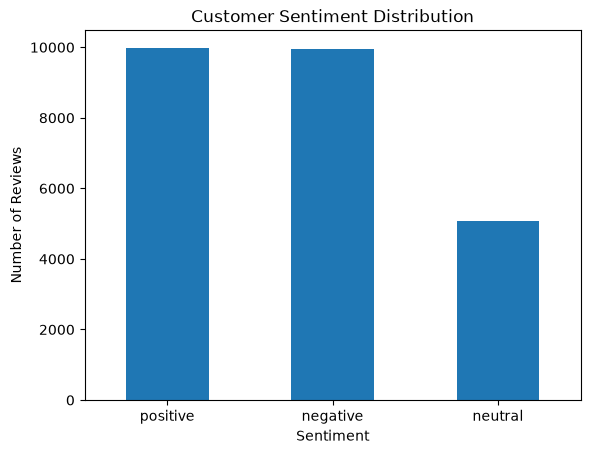

In [6]:
sentiment_counts = df["sentiment"].value_counts()
sentiment_counts.plot(
    kind="bar",
    title="Customer Sentiment Distribution"
)

plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

## Rating Distribution

## Customer Rating Distribution

Customer ratings from 1 to 5 are analyzed to understand the distribution of customer satisfaction.

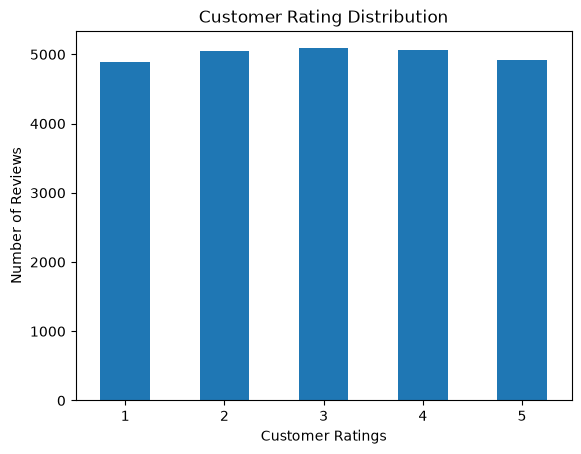

In [8]:
rating_counts = df["customer_rating"].value_counts().sort_index()

rating_counts.plot(
    kind="bar",
    title="Customer Rating Distribution"
)

plt.xlabel("Customer Ratings")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

## Sentiment vs Rating

In [9]:
sentiment_rating = pd.crosstab(
    df["customer_rating"],
    df["sentiment"]
)

sentiment_rating

sentiment,negative,neutral,positive
customer_rating,,,
1,4891,0,0
2,5046,0,0
3,0,5085,0
4,0,0,5066
5,0,0,4912


In [10]:
sentiment_rating_pct = pd.crosstab(
    df["customer_rating"],
    df["sentiment"],
    normalize="index"
) * 100

sentiment_rating_pct

sentiment,negative,neutral,positive
customer_rating,,,
1,100.0,0.0,0.0
2,100.0,0.0,0.0
3,0.0,100.0,0.0
4,0.0,0.0,100.0
5,0.0,0.0,100.0


## Category vs Sentiment

In [11]:
category_sentiment = pd.crosstab(
    df["product_category"],
    df["sentiment"]
)

category_sentiment

sentiment,negative,neutral,positive
product_category,,,
automobile,1126,583,1124
beauty,1104,537,1049
books,1141,583,1088
electronics,1061,545,1119
fashion,1148,534,1100
groceries,1108,585,1165
home & kitchen,1134,533,1059
sports,1049,553,1161
travel,1066,632,1113


In [12]:
# Percentage
category_sentiment_pct = pd.crosstab(
    df["product_category"],
    df["sentiment"],
    normalize="index"
) * 100

category_sentiment_pct.round(2)

sentiment,negative,neutral,positive
product_category,,,
automobile,39.75,20.58,39.68
beauty,41.04,19.96,39.00
books,40.58,20.73,38.69
electronics,38.94,20.00,41.06
fashion,41.27,19.19,39.54
groceries,38.77,20.47,40.76
home & kitchen,41.60,19.55,38.85
sports,37.97,20.01,42.02
travel,37.92,22.48,39.59


## Negative sentiment by category

In [14]:
negative_by_category = (
    df[df["sentiment"] == "negative"]
    .groupby("product_category")
    .size()
    .sort_values(ascending=False)
)

negative_by_category

product_category
fashion           1148
books             1141
home & kitchen    1134
automobile        1126
groceries         1108
beauty            1104
travel            1066
electronics       1061
sports            1049
dtype: int64

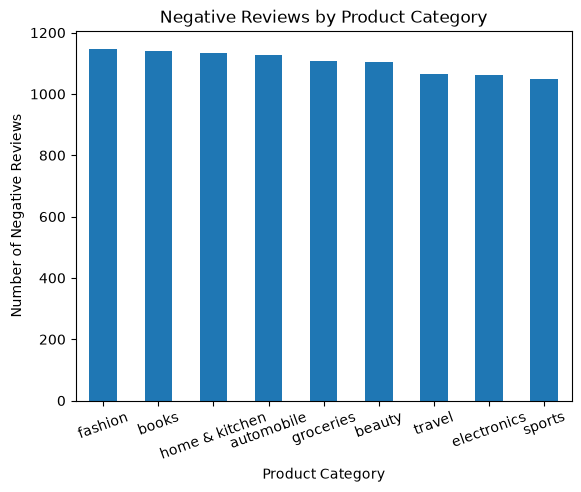

In [17]:
# Visualization
negative_by_category.plot(
    kind="bar",
    title="Negative Reviews by Product Category"
)

plt.xlabel("Product Category")
plt.ylabel("Number of Negative Reviews")
plt.xticks(rotation=20)
plt.show()

## Complaint Analysis

In [20]:
complaint_sentiment = pd.crosstab(
    df["complaint_registered"],
    df["sentiment"]
)

complaint_sentiment

sentiment,negative,neutral,positive
complaint_registered,,,
no,0,5085,9978
yes,9937,0,0


In [21]:
complaint_sentiment_pct = pd.crosstab(
    df["complaint_registered"],
    df["sentiment"],
    normalize="index"
) * 100

complaint_sentiment_pct.round(2)

sentiment,negative,neutral,positive
complaint_registered,,,
no,0.0,33.76,66.24
yes,100.0,0.00,0.00


## Issue resolution vs Sentiment

In [22]:
resolution_sentiment = pd.crosstab(
    df["issue_resolved"],
    df["sentiment"]
)

resolution_sentiment

sentiment,negative,neutral,positive
issue_resolved,,,
no,3317,1704,3386
yes,6620,3381,6592


In [25]:
resolution_sentiment_pct = pd.crosstab(
    df["issue_resolved"],
    df["sentiment"],
    normalize="index"
) * 100

resolution_sentiment_pct.round(2)

sentiment,negative,neutral,positive
issue_resolved,,,
no,39.46,20.27,40.28
yes,39.90,20.38,39.73


In [26]:
print("duplicate rows:", df.duplicated().sum())

duplicate rows: 0


## Customer Review Text Analysis

In [28]:
df["review_text"].head(10)

0          very disappointed with the quality.
1           fast delivery and great packaging.
2          very disappointed with the quality.
3      product stopped working after few days.
4                   neutral about the quality.
5        amazing experience, highly recommend!
6                       great value for money.
7    excellent product! exceeded expectations.
8            product is okay, nothing special.
9                       great value for money.
Name: review_text, dtype: str

In [31]:
for i, review in enumerate(df["review_text"].head(10), 1):
    print(f"{i}. {review}")

1. very disappointed with the quality.
2. fast delivery and great packaging.
3. very disappointed with the quality.
4. product stopped working after few days.
5. neutral about the quality.
6. amazing experience, highly recommend!
7. great value for money.
8. excellent product! exceeded expectations.
9. product is okay, nothing special.
10. great value for money.


## Review length

In [32]:
df["review_length"] = df["review_text"].str.len()

In [33]:
df[["review_text", "review_length"]].head()

,review_text,review_length
0,very disappointed with the quality.,35
1,fast delivery and great packaging.,34
2,very disappointed with the quality.,35
3,product stopped working after few days.,39
4,neutral about the quality.,26


In [37]:
print("Average review length:", round(df["review_length"].mean(), 2))
print("Minimum review length:", df["review_length"].min())
print("Maximum review length:", df["review_length"].max())

Average review length: 32.06
Minimum review length: 20
Maximum review length: 41


## Compare review length by sentiment

In [38]:
df.groupby("sentiment")["review_length"].agg(
    ["count", "mean", "min", "max"]
).round(2)

,count,mean,min,max
sentiment,,,,
negative,9937,31.49,20,39
neutral,5085,30.85,26,37
positive,9978,33.25,22,41


## Cleaning the review text

Create a separate column so we never destroy the original review.

In [41]:
df["clean_review"] = (
    df["review_text"].str.lower().str.strip()
)

In [42]:
df[["review_text", "clean_review"]].head(10)

,review_text,clean_review
0,very disappointed with the quality.,very disappointed with the quality.
1,fast delivery and great packaging.,fast delivery and great packaging.
2,very disappointed with the quality.,very disappointed with the quality.
3,product stopped working after few days.,product stopped working after few days.
4,neutral about the quality.,neutral about the quality.
5,"amazing experience, highly recommend!","amazing experience, highly recommend!"
6,great value for money.,great value for money.
7,excellent product! exceeded expectations.,excellent product! exceeded expectations.
8,"product is okay, nothing special.","product is okay, nothing special."
9,great value for money.,great value for money.


## Remove Punctuation

In [43]:
import re

In [44]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

In [45]:
df["clean_review"] = df["review_text"].apply(clean_text)

In [46]:
df[["review_text", "clean_review"]].head(10)

,review_text,clean_review
0,very disappointed with the quality.,very disappointed with the quality
1,fast delivery and great packaging.,fast delivery and great packaging
2,very disappointed with the quality.,very disappointed with the quality
3,product stopped working after few days.,product stopped working after few days
4,neutral about the quality.,neutral about the quality
5,"amazing experience, highly recommend!",amazing experience highly recommend
6,great value for money.,great value for money
7,excellent product! exceeded expectations.,excellent product exceeded expectations
8,"product is okay, nothing special.",product is okay nothing special
9,great value for money.,great value for money


## Tokenization

In [47]:
df["tokens"] = df["clean_review"].str.split()

In [48]:
df[["clean_review", "tokens"]].head()

,clean_review,tokens
0,very disappointed with the quality,"[very, disappointed, with, the, quality]"
1,fast delivery and great packaging,"[fast, delivery, and, great, packaging]"
2,very disappointed with the quality,"[very, disappointed, with, the, quality]"
3,product stopped working after few days,"[product, stopped, working, after, few, days]"
4,neutral about the quality,"[neutral, about, the, quality]"


The most common words

In [49]:
from collections import Counter
all_words = []

for tokens in df["tokens"]:
    all_words.extend(tokens)

word_counts = Counter(all_words)

word_counts.most_common(20)

[('the', 6978),
 ('product', 5942),
 ('delivery', 5023),
 ('quality', 4952),
 ('and', 3992),
 ('packaging', 3992),
 ('very', 3932),
 ('with', 3932),
 ('great', 3919),
 ('experience', 3092),
 ('was', 3038),
 ('amazing', 2109),
 ('highly', 2109),
 ('recommend', 2109),
 ('is', 2064),
 ('fine', 2049),
 ('late', 2044),
 ('poor', 2044),
 ('not', 2026),
 ('worth', 2026)]

## Remove stopwords

In [8]:
import nltk

nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\SAYALI\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [59]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

## Removing stopwords

In [60]:
df["tokens_clean"] = df["tokens"].apply(
    lambda words: [
        word for word in words
        if word not in stop_words
    ]
)

Check

In [61]:
df[["tokens", "tokens_clean"]].head()

,tokens,tokens_clean
0,"[very, disappointed, with, the, quality]","[disappointed, quality]"
1,"[fast, delivery, and, great, packaging]","[fast, delivery, great, packaging]"
2,"[very, disappointed, with, the, quality]","[disappointed, quality]"
3,"[product, stopped, working, after, few, days]","[product, stopped, working, days]"
4,"[neutral, about, the, quality]","[neutral, quality]"


In [67]:
all_clean_words = {}

word_counts_clean = Counter(df["tokens_clean"].explode())

top_words = word_counts_clean.most_common(20)

top_words

[('product', 5942),
 ('delivery', 5023),
 ('quality', 4952),
 ('packaging', 3992),
 ('great', 3919),
 ('experience', 3092),
 ('amazing', 2109),
 ('highly', 2109),
 ('recommend', 2109),
 ('fine', 2049),
 ('late', 2044),
 ('poor', 2044),
 ('worth', 2026),
 ('price', 2026),
 ('customer', 2007),
 ('service', 2007),
 ('unhelpful', 2007),
 ('satisfied', 1980),
 ('value', 1971),
 ('money', 1971)]

## Separating positive and negative reviews

In [69]:
# Negative reviews
negative_reviews = df[df["sentiment"] == "negative"].copy()

negative_reviews.shape

(9937, 17)

In [73]:
# Positive Reviews

positive_reviews = df[df["sentiment"] == "positive"].copy()

positive_reviews.shape

(9978, 17)

In [74]:
# Negative words

negative_words = []

for words in negative_reviews["tokens_clean"]:
    negative_words.extend(words)

negative_word_counts = Counter(negative_words)

negative_word_counts.most_common(20)

[('late', 2044),
 ('delivery', 2044),
 ('poor', 2044),
 ('packaging', 2044),
 ('worth', 2026),
 ('price', 2026),
 ('customer', 2007),
 ('service', 2007),
 ('unhelpful', 2007),
 ('disappointed', 1952),
 ('quality', 1952),
 ('product', 1908),
 ('stopped', 1908),
 ('working', 1908),
 ('days', 1908)]

In [76]:
# Positive Words

positive_words = []

for words in positive_reviews["tokens_clean"]:
    positive_words.extend(words)

positive_words_counts = Counter(positive_words)

positive_words_counts.most_common(20)

[('great', 3919),
 ('amazing', 2109),
 ('experience', 2109),
 ('highly', 2109),
 ('recommend', 2109),
 ('satisfied', 1980),
 ('quality', 1980),
 ('value', 1971),
 ('money', 1971),
 ('excellent', 1970),
 ('product', 1970),
 ('exceeded', 1970),
 ('expectations', 1970),
 ('fast', 1948),
 ('delivery', 1948),
 ('packaging', 1948)]

## VADER Sentiment Analysis

VADER is applied to the review text to generate a compound sentiment score.

The compound score is then converted into positive, negative, or neutral labels using defined thresholds.

In [81]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

In [82]:
# Calculating Sentiment Scores

df["vader_scores"] = df["review_text"].apply(
    lambda text: analyzer.polarity_scores(text)
)

df[["review_text", "vader_scores"]].head(10)

,review_text,vader_scores
0,very disappointed with the quality.,"{'neg': 0.459, 'neu': 0.541, 'pos': 0.0, 'comp..."
1,fast delivery and great packaging.,"{'neg': 0.0, 'neu': 0.494, 'pos': 0.506, 'comp..."
2,very disappointed with the quality.,"{'neg': 0.459, 'neu': 0.541, 'pos': 0.0, 'comp..."
3,product stopped working after few days.,"{'neg': 0.275, 'neu': 0.725, 'pos': 0.0, 'comp..."
4,neutral about the quality.,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound..."
5,"amazing experience, highly recommend!","{'neg': 0.0, 'neu': 0.225, 'pos': 0.775, 'comp..."
6,great value for money.,"{'neg': 0.0, 'neu': 0.235, 'pos': 0.765, 'comp..."
7,excellent product! exceeded expectations.,"{'neg': 0.0, 'neu': 0.429, 'pos': 0.571, 'comp..."
8,"product is okay, nothing special.","{'neg': 0.315, 'neu': 0.419, 'pos': 0.265, 'co..."
9,great value for money.,"{'neg': 0.0, 'neu': 0.235, 'pos': 0.765, 'comp..."


In [83]:
# Extract the compound score

df["vader_compound"] = df["vader_scores"].apply(
    lambda x: x["compound"]
)

df[["review_text", "vader_compound"]].head(10)

,review_text,vader_compound
0,very disappointed with the quality.,-0.5256
1,fast delivery and great packaging.,0.6249
2,very disappointed with the quality.,-0.5256
3,product stopped working after few days.,-0.2263
4,neutral about the quality.,0.0000
5,"amazing experience, highly recommend!",0.7836
6,great value for money.,0.7579
7,excellent product! exceeded expectations.,0.6114
8,"product is okay, nothing special.",-0.0920
9,great value for money.,0.7579


### Convert VADER Scores into Sentiment Labels

The VADER compound score is converted into a sentiment label using the following thresholds:

- Score >= 0.05 → Positive
- Score <= -0.05 → Negative
- Otherwise → Neutral

In [84]:
# Convert score into our own sentiment label

def vader_label(score):
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"

df["vader_sentiment"] = df["vader_compound"].apply(vader_label)

In [85]:
df[["review_text", "sentiment", "vader_compound", "vader_sentiment"]].head(20)

,review_text,sentiment,vader_compound,vader_sentiment
0,very disappointed with the quality.,negative,-0.5256,negative
1,fast delivery and great packaging.,positive,0.6249,positive
2,very disappointed with the quality.,negative,-0.5256,negative
3,product stopped working after few days.,negative,-0.2263,negative
4,neutral about the quality.,neutral,0.0000,neutral
5,"amazing experience, highly recommend!",positive,0.7836,positive
6,great value for money.,positive,0.7579,positive
7,excellent product! exceeded expectations.,positive,0.6114,positive
8,"product is okay, nothing special.",neutral,-0.0920,negative
9,great value for money.,positive,0.7579,positive


## VADER vs Existing Sentiment

The VADER-generated sentiment labels are compared with the existing sentiment labels in the dataset.

A cross-tabulation is used to identify agreements and disagreements between the two approaches.

In [86]:
# dataset sentiment vs vader

pd.crosstab(
    df["sentiment"],
    df["vader_sentiment"]
)

vader_sentiment,negative,neutral,positive
sentiment,,,
negative,7930,2007,0
neutral,1033,2003,2049
positive,0,0,9978


### Sentiment Agreement

The agreement percentage measures the proportion of records where the existing sentiment label and VADER sentiment label are the same.

In [87]:
# Calculate agreement
agreement = (
    df["sentiment"] == df["vader_sentiment"]
).mean()

print("Agreement:", round(agreement * 100, 2), "%")

Agreement: 79.64 %


### Sentiment Disagreements

Records where the existing sentiment and VADER sentiment differ are extracted for further inspection.

In [88]:
# Finding disagreements

disagreements = df[
    df["sentiment"] != df["vader_sentiment"]
].copy()

print("Number of disagreements:", len(disagreements))

Number of disagreements: 5089


In [89]:
disagreements[
    [
        "review_text",
        "sentiment",
        "vader_compound",
        "vader_sentiment"
    ]
].head(20)

,review_text,sentiment,vader_compound,vader_sentiment
8,"product is okay, nothing special.",neutral,-0.0920,negative
14,customer service was unhelpful.,negative,0.0000,neutral
23,customer service was unhelpful.,negative,0.0000,neutral
28,works fine but could be better.,neutral,0.6428,positive
34,works fine but could be better.,neutral,0.6428,positive
37,customer service was unhelpful.,negative,0.0000,neutral
42,works fine but could be better.,neutral,0.6428,positive
57,"product is okay, nothing special.",neutral,-0.0920,negative
60,"product is okay, nothing special.",neutral,-0.0920,negative
66,customer service was unhelpful.,negative,0.0000,neutral


In [90]:
# Compare average VADER score by existing sentiment

df.groupby("sentiment")["vader_compound"].agg(
    ["count", "mean", "min", "max"]
).round(3)

,count,mean,min,max
sentiment,,,,
negative,9937,-0.279,-0.526,0.000
neutral,5085,0.151,-0.092,0.643
positive,9978,0.652,0.475,0.784


## Business Analysis

## 11. Negative Reviews by Product Category

Negative reviews are grouped by product category and sorted in descending order to identify categories with the largest number of negative reviews.

### Visualization: Negative Reviews by Product Category

A bar chart is created to visualize the number of negative reviews across product categories.

## Which categories have the highest negative-review rate?

In [91]:
category_sentiment = pd.crosstab(
    df["product_category"],
    df["sentiment"]
)

category_sentiment["negative_rate"] = (
    category_sentiment["negative"] /
    category_sentiment.sum(axis=1) * 100
)

category_sentiment = category_sentiment.sort_values(
    "negative_rate",
    ascending=False
)

category_sentiment.round(2)

sentiment,negative,neutral,positive,negative_rate
product_category,,,,
home & kitchen,1134,533,1059,41.60
fashion,1148,534,1100,41.27
beauty,1104,537,1049,41.04
books,1141,583,1088,40.58
automobile,1126,583,1124,39.75
electronics,1061,545,1119,38.94
groceries,1108,585,1165,38.77
sports,1049,553,1161,37.97
travel,1066,632,1113,37.92


## Platform Analysis

Customer sentiment is analyzed across platforms to compare negative-review rates and customer ratings.

## Which platforms have the highest negative sentiment?

In [6]:
platform_sentiment = pd.crosstab(
    df["platform"],
    df["sentiment"]
)

### Negative Sentiment Rate by Platform

The negative-review rate is calculated for each platform to compare the proportion of negative reviews.

In [7]:
platform_sentiment["negative_rate"] = (
    platform_sentiment["negative"] /
    platform_sentiment.sum(axis=1) * 100
)

platform_sentiment = platform_sentiment.sort_values(
    "negative_rate",
    ascending=False
)

platform_sentiment.round(2)

sentiment,negative,neutral,positive,negative_rate
platform,,,,
flipkart,543,251,470,42.96
snapdeal,536,243,510,41.58
croma,526,254,486,41.55
shopclues,506,240,474,41.48
bigbasket,510,232,488,41.46
nykaa,526,264,511,40.43
others,518,253,515,40.28
meesho,492,247,501,39.68
lenskart,492,269,480,39.65


### Platform Performance Summary

The platform-level analysis combines review volume, average rating, and negative-review rate.

In [93]:
# Calculating platform volume
platform_summary = df.groupby("platform").agg(
    total_reviews=("customer_id", "count"),
    avg_rating=("customer_rating", "mean")
)

platform_summary["negative_rate"] = (
    df.groupby("platform")["sentiment"]
    .apply(lambda x: (x == "negative").mean() * 100)
)

platform_summary.sort_values(
    "negative_rate",
    ascending=False
).round(2)

,total_reviews,avg_rating,negative_rate
platform,,,
flipkart,1264,2.94,42.96
snapdeal,1289,2.97,41.58
croma,1266,2.96,41.55
shopclues,1220,2.97,41.48
bigbasket,1230,2.96,41.46
nykaa,1301,2.97,40.43
others,1286,2.99,40.28
meesho,1240,3.02,39.68
lenskart,1241,2.97,39.65


### Negative Sentiment Rate by Region

The negative-review rate is calculated for each region to compare the proportion of negative reviews.

## Which regions have the highest negative sentiment?

In [94]:
region_sentiment = pd.crosstab(
    df["region"],
    df["sentiment"]
)

region_sentiment["negative_rate"] = (
    region_sentiment["negative"] /
    region_sentiment.sum(axis=1) * 100
)

region_sentiment.sort_values(
    "negative_rate",
    ascending=False
).round(2)

sentiment,negative,neutral,positive,negative_rate
region,,,,
west,2101,1000,1980,41.35
east,2004,990,2007,40.07
north,1962,996,2005,39.53
south,1976,1067,1979,39.35
central,1894,1032,2007,38.39


### Regional Summary

The regional summary combines total review volume and average customer rating.

In [95]:
region_summary = df.groupby("region").agg(
    total_reviews=("customer_id", "count"),
    avg_rating=("customer_rating", "mean")
)

region_summary.round(2)

,total_reviews,avg_rating
region,,
central,4933,3.04
east,5001,3.01
north,4963,3.02
south,5022,2.99
west,5081,2.96


## Complaint Analysis

Complaint registration is compared with customer sentiment to understand how complaints are distributed across sentiment categories.

## Are complaints associated with negative sentiment?

In [96]:
complaint_sentiment = pd.crosstab(
    df["complaint_registered"],
    df["sentiment"]
)

complaint_sentiment

sentiment,negative,neutral,positive
complaint_registered,,,
no,0,5085,9978
yes,9937,0,0


### Complaint Sentiment Percentage

The percentage distribution is calculated within each complaint-registration group.

In [97]:
complaint_sentiment_pct = pd.crosstab(
    df["complaint_registered"],
    df["sentiment"],
    normalize="index"
) * 100

complaint_sentiment_pct.round(2)

sentiment,negative,neutral,positive
complaint_registered,,,
no,0.0,33.76,66.24
yes,100.0,0.00,0.00


## Does issue resolution differ by sentiment?

In [98]:
resolution_sentiment = pd.crosstab(
    df["issue_resolved"],
    df["sentiment"]
)

resolution_sentiment

sentiment,negative,neutral,positive
issue_resolved,,,
no,3317,1704,3386
yes,6620,3381,6592


In [99]:
resolution_sentiment_pct = pd.crosstab(
    df["issue_resolved"],
    df["sentiment"],
    normalize="index"
) * 100

resolution_sentiment_pct.round(2)

sentiment,negative,neutral,positive
issue_resolved,,,
no,39.46,20.27,40.28
yes,39.90,20.38,39.73


## Does response time differ by sentiment?

In [100]:
response_by_sentiment = df.groupby("sentiment")[
    "response_time_hours"
].agg(
    ["count", "mean", "median", "min", "max"]
)

response_by_sentiment.round(2)

,count,mean,median,min,max
sentiment,,,,,
negative,9937,36.02,36.0,1,71
neutral,5085,36.09,36.0,1,71
positive,9978,35.99,36.0,1,71


In [101]:
response_by_resolution = df.groupby(
    "issue_resolved"
)["response_time_hours"].agg(
    ["count", "mean", "median", "min", "max"]
)

response_by_resolution.round(2)

,count,mean,median,min,max
issue_resolved,,,,,
no,8407,59.70,60.0,48,71
yes,16593,24.03,24.0,1,47


## What are the main customer pain points?

In [102]:
pain_points = {
    "Delivery": ["delivery", "late"],
    "Product Quality": ["quality", "stopped", "working"],
    "Packaging": ["packaging", "poor"],
    "Price / Value": ["price", "worth", "value", "money"],
    "Customer Service": ["customer", "service", "unhelpful"]
}

for category, keywords in pain_points.items():
    count = negative_reviews["clean_review"].apply(
        lambda text: any(word in text for word in keywords)
    ).sum()

    percentage = count / len(negative_reviews) * 100

    print(
        category,
        ":", count,
        "reviews |",
        round(percentage, 2),
        "%"
    )

Delivery : 2044 reviews | 20.57 %
Product Quality : 3860 reviews | 38.84 %
Packaging : 2044 reviews | 20.57 %
Price / Value : 2026 reviews | 20.39 %
Customer Service : 2007 reviews | 20.2 %


In [5]:
df.to_csv(
    r"D:\Data_Analytics\Customer_Sentiment_Analysis\data\cleaned_customer_sentiment.csv",
    index=False,
)

print("File saved successfully!")

File saved successfully!


In [7]:
import os

path = r"D:\Data_Analytics\Customer_Sentiment_Analysis\data\cleaned_customer_sentiment.csv"

print("File exists:", os.path.exists(path))
print("Saved at:", path)

File exists: True
Saved at: D:\Data_Analytics\Customer_Sentiment_Analysis\data\cleaned_customer_sentiment.csv


## Limitations

- Sentiment is directly mapped to customer rating in this dataset.
- Complaint registration is directly associated with negative sentiment.
- Category, platform, and regional differences are descriptive and should not be interpreted as causal relationships.
- Keyword-based pain-point analysis may not capture context, sarcasm, or synonyms.
- VADER is a lexicon-based approach and may disagree with the existing sentiment labels.

## Business Insights

### Key Findings

- The dataset contains 25,000 customer reviews.
- Positive reviews: 9,978.
- Negative reviews: 9,937.
- Neutral reviews: 5,085.
- Average customer rating: 3.00.
- Home & Kitchen has a 41.60% negative-review rate.
- Flipkart has a 42.96% negative-review rate in this dataset.
- West has a 41.35% negative-review rate.
- Average response time is approximately 36 hours.
- 16,593 issues are marked as resolved.
- Overall issue resolution rate is 66.37%.
- VADER agrees with the existing sentiment labels for 79.64% of records.

## Conclusion

The analysis provides an end-to-end view of customer sentiment using python.

The project combines data cleaning, exploratory data analysis, statistical summaries, visualization, sentiment analysis, and business-oriented interpretation.